# 03 — Explainability

## Objetivo
Este notebook documenta la explicabilidad del modelo final seleccionado, la **regresión logística**, desde tres niveles complementarios:

1. **Explicabilidad global**: qué variables son las más influyentes en el modelo.
2. **Explicabilidad local**: por qué el modelo asigna alto o bajo riesgo a clientes concretos.
3. **Explicabilidad agrupada**: qué perfil caracteriza al top 10% de clientes con mayor riesgo estimado.

## Preguntas que responde
- ¿Qué variables empujan el churn hacia arriba o hacia abajo?
- ¿Cómo se explica una predicción individual?
- ¿Qué patrón colectivo caracteriza al grupo de mayor riesgo?
- ¿Cómo se conecta la explicabilidad con la decisión de negocio?

In [16]:
from pathlib import Path
import sys

# Buscar la raíz del proyecto (la carpeta que contiene "src")
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = C:\repos\tfm-proyecto1-churn


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import sys
import os

# Ajuste de path si es necesario para importar desde src/
sys.path.append(os.path.abspath(os.path.join('..')))

from src.models.train_logistic import (
    build_logistic_pipeline,
    prepare_train_test_split,
)
from src.explainability.global_explainability import (
    load_or_train_logistic_model,
    build_odds_ratio_table,
    build_selected_summary,
)
from src.explainability.grouped_explainability import (
    build_grouped_explainability_tables,
)

In [18]:
clf_log = load_or_train_logistic_model()
X_train, X_test, y_train, y_test = prepare_train_test_split()

## BLOQUE A — Explicabilidad Global
Analizamos el peso y la dirección de cada variable en el modelo a través de sus coeficientes y *Odds Ratios*.

In [19]:
coef_df = build_odds_ratio_table(clf_log)
coef_df.head(15)

,feature,coefficient,odds_ratio,abs_coefficient,direction
0,num__tenure,-1.255202,0.285018,1.255202,Reduce riesgo de churn
1,cat__Contract_Two year,-0.759402,0.467946,0.759402,Reduce riesgo de churn
2,cat__InternetService_Fiber optic,0.648027,1.911766,0.648027,Aumenta riesgo de churn
3,cat__InternetService_DSL,-0.643642,0.525375,0.643642,Reduce riesgo de churn
4,num__MonthlyCharges,-0.601168,0.548171,0.601168,Reduce riesgo de churn
5,cat__Contract_Month-to-month,0.585998,1.796784,0.585998,Aumenta riesgo de churn
6,num__TotalCharges,0.532592,1.703341,0.532592,Aumenta riesgo de churn
7,cat__PaperlessBilling_No,-0.330735,0.718396,0.330735,Reduce riesgo de churn
8,cat__DeviceProtection_No internet service,-0.292955,0.746056,0.292955,Reduce riesgo de churn
9,cat__OnlineSecurity_No internet service,-0.292955,0.746056,0.292955,Reduce riesgo de churn


In [20]:
summary_df = build_selected_summary(coef_df)
summary_df

,variable,feature,coefficient,odds_ratio,direction,interpretation
0,Tenure (antigüedad del cliente),num__tenure,-1.255,0.285,Reduce riesgo de churn,Una mayor antigüedad del cliente se asocia con...
1,Contrato: Two year,cat__Contract_Two year,-0.759,0.468,Reduce riesgo de churn,Tener un contrato de dos años se asocia con un...
2,Contrato: Month-to-month,cat__Contract_Month-to-month,0.586,1.797,Aumenta riesgo de churn,El contrato mensual se asocia con un aumento i...
3,InternetService: Fiber optic,cat__InternetService_Fiber optic,0.648,1.912,Aumenta riesgo de churn,La categoría Fiber optic se asocia con mayores...
4,InternetService: DSL,cat__InternetService_DSL,-0.644,0.525,Reduce riesgo de churn,La categoría DSL se asocia con menor riesgo es...
5,PaymentMethod: Electronic check,cat__PaymentMethod_Electronic check,0.206,1.228,Aumenta riesgo de churn,Electronic check se asocia con un aumento mode...
6,MonthlyCharges,num__MonthlyCharges,-0.601,0.548,Reduce riesgo de churn,El efecto de MonthlyCharges cambia respecto al...
7,TotalCharges,num__TotalCharges,0.533,1.703,Aumenta riesgo de churn,"TotalCharges mantiene una asociación positiva,..."


C:\repos\tfm-proyecto1-churn\reports\figures\models\odds_ratio_plot.png


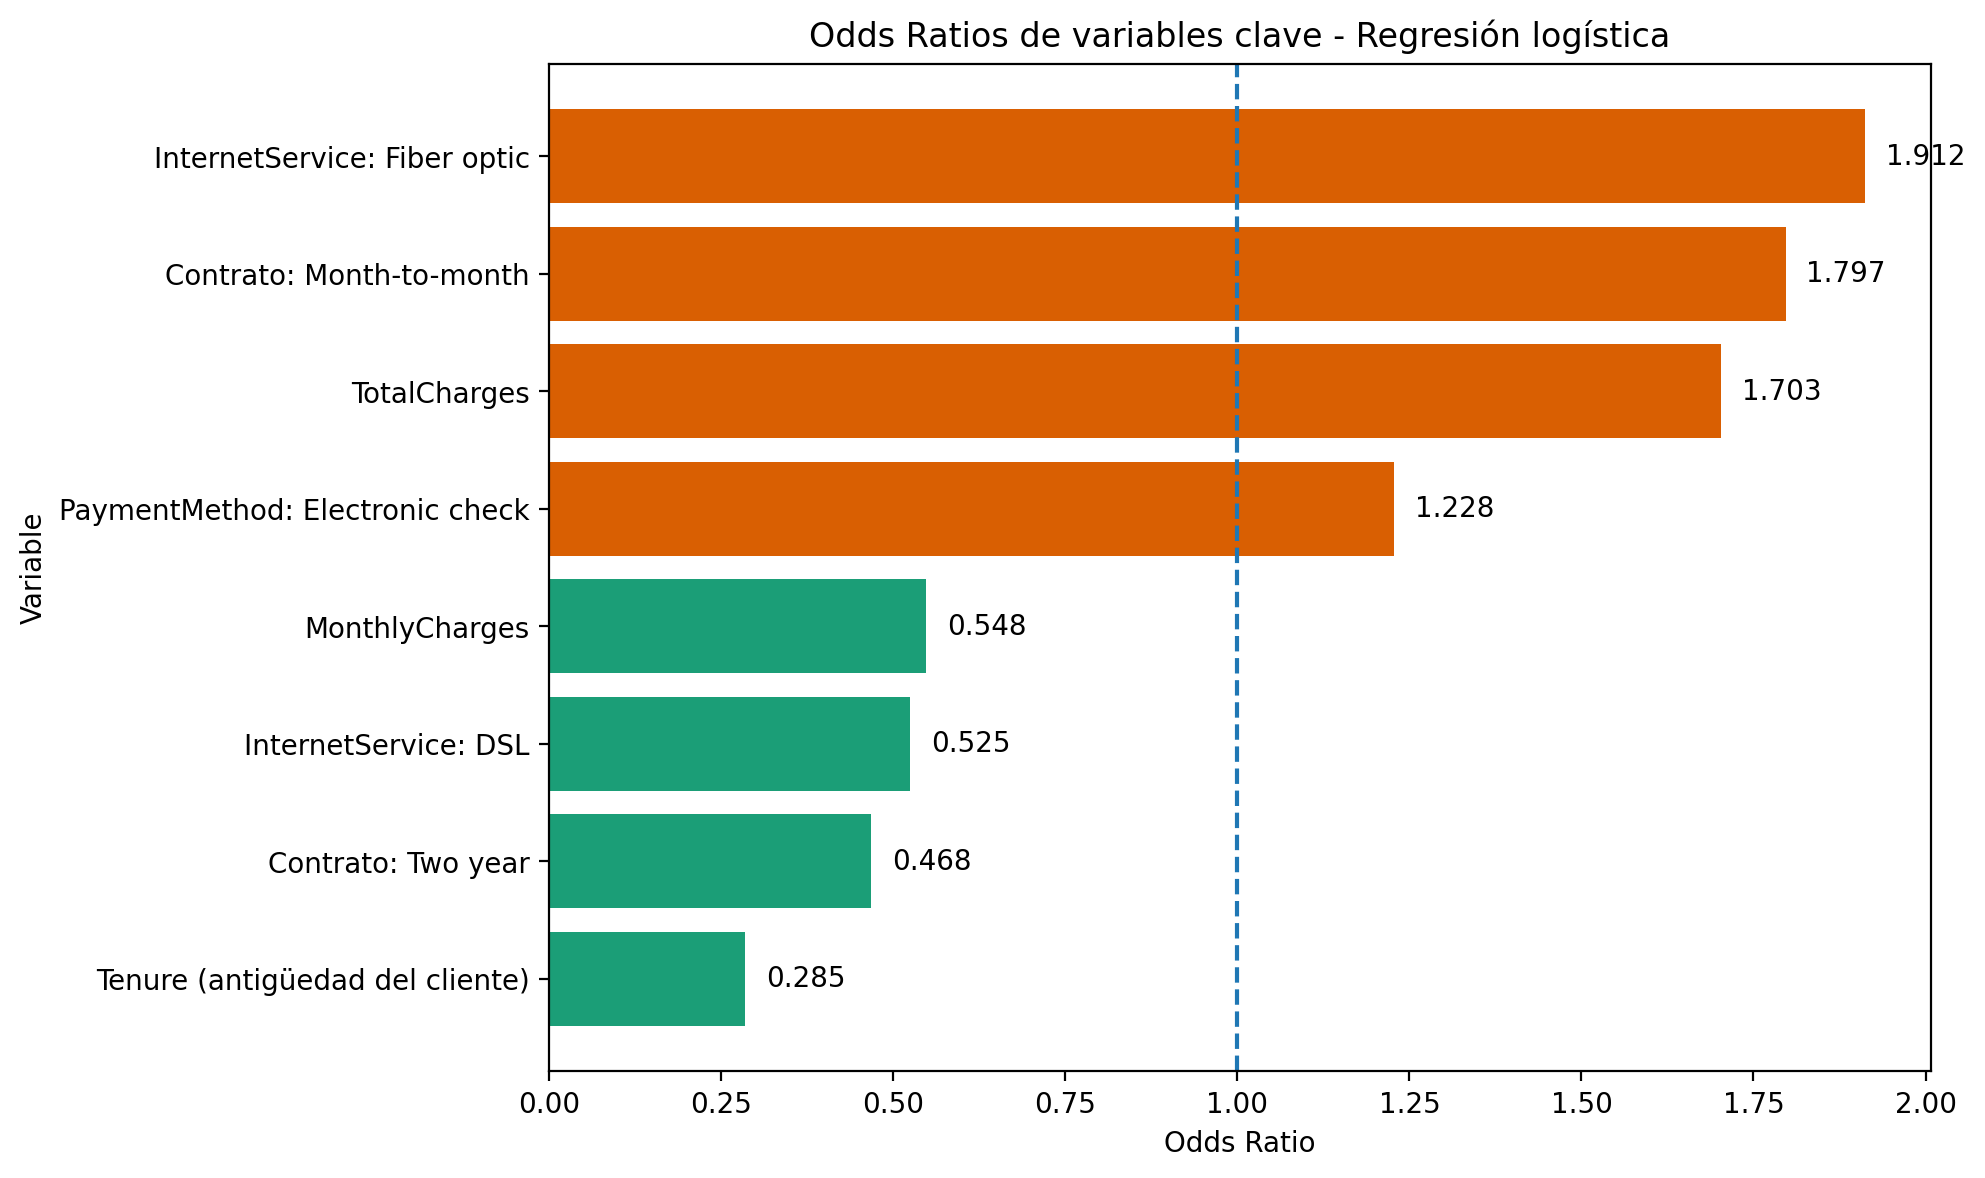

In [21]:
from IPython.display import Image, display
from pathlib import Path

odds_plot_path = PROJECT_ROOT / "reports" / "figures" / "models" / "odds_ratio_plot.png"

print(odds_plot_path)
display(Image(filename=str(odds_plot_path)))

## Interpretación global

La explicabilidad global confirma que la **antigüedad del cliente (`tenure`)** y la **estabilidad contractual** son los principales factores protectores frente al churn. En sentido contrario, el contrato mensual, el servicio `Fiber optic` y el método de pago `Electronic check` aparecen asociados con mayor riesgo estimado.

Estos resultados son coherentes con el EDA y refuerzan la validez del modelo desde un punto de vista tanto estadístico como de negocio.

## BLOQUE B — Explicabilidad Local
Para entender cómo el modelo calcula la probabilidad exacta de un individuo, extraemos el peso de cada variable para clientes específicos de nuestro conjunto de test.

In [22]:
preprocessor = clf_log.named_steps["preprocessor"]
model = clf_log.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
coefs = model.coef_
intercept = model.intercept_

X_test_transformed = preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

contrib_df = X_test_transformed_df.mul(coefs, axis=1)

log_odds = intercept + contrib_df.sum(axis=1)
proba_from_contrib = 1 / (1 + np.exp(-log_odds))

y_proba = clf_log.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.50).astype(int)

local_summary = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "y_proba": y_proba
}, index=X_test.index)

In [23]:
tp_candidates = local_summary[
    (local_summary["y_true"] == 1) & (local_summary["y_pred"] == 1)
]
case_tp = tp_candidates.sort_values("y_proba", ascending=False).head(1).index[0]

fp_candidates = local_summary[
    (local_summary["y_true"] == 0) & (local_summary["y_pred"] == 1)
]
case_fp = fp_candidates.sort_values("y_proba", ascending=False).head(1).index[0]

print("Caso TP seleccionado:", case_tp, type(case_tp))
print("Caso FP seleccionado:", case_fp, type(case_fp))

Caso TP seleccionado: 3380 <class 'numpy.int64'>
Caso FP seleccionado: 3346 <class 'numpy.int64'>


In [24]:
def explain_case(case_id, top_n=8):
    # Si viene como Index o lista de un solo elemento, extraer el valor
    if hasattr(case_id, "__len__") and not isinstance(case_id, (str, bytes)):
        if not isinstance(case_id, (int, float)):
            try:
                case_id = list(case_id)[0]
            except Exception:
                pass

    print("\n==============================")
    print(f"Explicación local del caso {case_id}")
    print("==============================")

    print("\nDatos originales del cliente:")
    display(X_test.loc[[case_id]])

    print("\nResultado del modelo:")
    print(local_summary.loc[case_id])

    case_contrib = contrib_df.loc[case_id].sort_values()

    print("\nTop variables que reducen churn en este caso:")
    display(
        case_contrib.head(top_n)
        .reset_index()
        .rename(columns={"index": "feature", case_id: "contribution"})
    )

    print("\nTop variables que aumentan churn en este caso:")
    display(
        case_contrib.tail(top_n)
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "feature", case_id: "contribution"})
    )

    print("\nChequeo de consistencia:")
    print("Log-odds:", round(log_odds.loc[case_id], 4))
    print("Probabilidad calculada desde contribuciones:", round(proba_from_contrib.loc[case_id], 4))
    print("Probabilidad del pipeline:", round(local_summary.loc[case_id, "y_proba"], 4))

In [25]:
explain_case(case_tp, top_n=8)


Explicación local del caso 3380

Datos originales del cliente:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.1,95.1



Resultado del modelo:
y_true     1.000000
y_pred     1.000000
y_proba    0.855041
Name: 3380, dtype: float64

Top variables que reducen churn en este caso:


,feature,contribution
0,num__MonthlyCharges,-0.601858
1,num__TotalCharges,-0.515119
2,cat__PhoneService_Yes,-0.158065
3,cat__Partner_Yes,-0.133534
4,cat__gender_Male,-0.133340
5,cat__SeniorCitizen_1,-0.070924
6,cat__Dependents_No,-0.032387
7,cat__DeviceProtection_No,-0.026421



Top variables que aumentan churn en este caso:


,feature,contribution
0,num__tenure,1.608697
1,cat__InternetService_Fiber optic,0.648027
2,cat__Contract_Month-to-month,0.585998
3,cat__StreamingMovies_Yes,0.212270
4,cat__StreamingTV_Yes,0.211922
5,cat__PaymentMethod_Electronic check,0.205585
6,cat__OnlineSecurity_No,0.165550
7,cat__TechSupport_No,0.141320



Chequeo de consistencia:
Log-odds: 1.7747
Probabilidad calculada desde contribuciones: 0.855
Probabilidad del pipeline: 0.855


**Lectura del True Positive (TP):**
Este caso ilustra a la perfección el perfil de fuga clásico. El modelo detecta un riesgo extremo impulsado por una combinación letal: baja antigüedad, contrato mensual, uso de fibra óptica y ausencia de servicios de soporte/seguridad. El modelo acierta de pleno.

In [26]:
explain_case(case_fp, top_n=8)


Explicación local del caso 3346

Datos originales del cliente:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05



Resultado del modelo:
y_true     0.000000
y_pred     1.000000
y_proba    0.817939
Name: 3346, dtype: float64

Top variables que reducen churn en este caso:


,feature,contribution
0,num__TotalCharges,-0.493864
1,num__MonthlyCharges,-0.381423
2,cat__StreamingTV_No,-0.207537
3,cat__PhoneService_Yes,-0.158065
4,cat__gender_Female,-0.155230
5,cat__Partner_No,-0.155036
6,cat__SeniorCitizen_1,-0.070924
7,cat__Dependents_No,-0.032387



Top variables que aumentan churn en este caso:


,feature,contribution
0,num__tenure,1.557603
1,cat__InternetService_Fiber optic,0.648027
2,cat__Contract_Month-to-month,0.585998
3,cat__StreamingMovies_Yes,0.212270
4,cat__PaymentMethod_Electronic check,0.205585
5,cat__OnlineSecurity_No,0.165550
6,cat__TechSupport_No,0.141320
7,cat__MultipleLines_Yes,0.113364



Chequeo de consistencia:
Log-odds: 1.5024
Probabilidad calculada desde contribuciones: 0.8179
Probabilidad del pipeline: 0.8179


**Lectura del False Positive (FP):**
Este cliente tiene un perfil de altísimo riesgo (matemáticamente casi idéntico a un *churner*), pero en la realidad decidió quedarse. Esto es crucial: el modelo no emite certezas absolutas, sino que estima probabilidades basadas en perfiles de riesgo histórico.

### Interpretación local

La explicabilidad local muestra que el modelo no asigna riesgo por una sola variable, sino por la combinación de múltiples contribuciones. Los casos analizados confirman que la baja antigüedad, el contrato mensual, la fibra y la ausencia de soporte o seguridad empujan fuertemente el riesgo hacia arriba. También ilustran que un cliente puede presentar un perfil claramente frágil y aun así no abandonar, lo que refuerza la idea de que el modelo estima probabilidades, no certezas absolutas.

## BLOQUE C — Explicabilidad Agrupada
Analizamos el comportamiento colectivo del 10% de clientes con mayor probabilidad de fuga de nuestra cartera.

In [27]:
top10_profile_df, top10_protective_df = build_grouped_explainability_tables(k=0.10)

top10_profile_df
top10_protective_df

,feature,mean_contrib_top10,mean_contrib_rest,diff_top10_vs_rest,group_effect,topk_fraction,topk_size,min_probability_in_topk
0,num__TotalCharges,-0.399146,0.018613,-0.417759,Aleja del Top10 riesgo,0.1,140,0.6615
1,num__MonthlyCharges,-0.346100,0.056813,-0.402913,Aleja del Top10 riesgo,0.1,140,0.6615
2,cat__Partner_No,-0.117384,-0.076968,-0.040416,Aleja del Top10 riesgo,0.1,140,0.6615
3,cat__StreamingTV_No,-0.120075,-0.082263,-0.037813,Aleja del Top10 riesgo,0.1,140,0.6615
4,cat__StreamingMovies_No,-0.100973,-0.081909,-0.019064,Aleja del Top10 riesgo,0.1,140,0.6615
5,cat__SeniorCitizen_1,-0.026343,-0.009501,-0.016842,Aleja del Top10 riesgo,0.1,140,0.6615
6,cat__DeviceProtection_No,-0.020948,-0.010660,-0.010288,Aleja del Top10 riesgo,0.1,140,0.6615
7,cat__Dependents_No,-0.030768,-0.021566,-0.009202,Aleja del Top10 riesgo,0.1,140,0.6615
8,cat__PhoneService_Yes,-0.151291,-0.143491,-0.007799,Aleja del Top10 riesgo,0.1,140,0.6615
9,cat__DeviceProtection_Yes,0.006381,0.010803,-0.004422,Aleja del Top10 riesgo,0.1,140,0.6615


In [28]:
print("Variables que caracterizan al Top 10% de riesgo:")
top10_profile_df

Variables que caracterizan al Top 10% de riesgo:


,feature,mean_contrib_top10,mean_contrib_rest,diff_top10_vs_rest,group_effect,topk_fraction,topk_size,min_probability_in_topk
0,num__tenure,1.320016,-0.113317,1.433333,Caracteriza Top10 riesgo,0.1,140,0.6615
1,cat__InternetService_Fiber optic,0.620255,0.244606,0.375649,Caracteriza Top10 riesgo,0.1,140,0.6615
2,cat__Contract_Month-to-month,0.585998,0.292306,0.293692,Caracteriza Top10 riesgo,0.1,140,0.6615
3,cat__InternetService_DSL,-0.027585,-0.242444,0.214859,Caracteriza Top10 riesgo,0.1,140,0.6615
4,cat__Contract_Two year,0.000000,-0.201071,0.201071,Caracteriza Top10 riesgo,0.1,140,0.6615
5,cat__PaperlessBilling_No,-0.016537,-0.146472,0.129935,Caracteriza Top10 riesgo,0.1,140,0.6615
6,cat__PaymentMethod_Electronic check,0.170342,0.057998,0.112344,Caracteriza Top10 riesgo,0.1,140,0.6615
7,cat__OnlineSecurity_No,0.164367,0.073317,0.091050,Caracteriza Top10 riesgo,0.1,140,0.6615
8,cat__TechSupport_No,0.137282,0.063031,0.074250,Caracteriza Top10 riesgo,0.1,140,0.6615
9,cat__Dependents_Yes,-0.012809,-0.085596,0.072787,Caracteriza Top10 riesgo,0.1,140,0.6615


In [29]:
print("Variables que más alejan del Top 10% de riesgo:")
top10_protective_df

Variables que más alejan del Top 10% de riesgo:


,feature,mean_contrib_top10,mean_contrib_rest,diff_top10_vs_rest,group_effect,topk_fraction,topk_size,min_probability_in_topk
0,num__TotalCharges,-0.399146,0.018613,-0.417759,Aleja del Top10 riesgo,0.1,140,0.6615
1,num__MonthlyCharges,-0.346100,0.056813,-0.402913,Aleja del Top10 riesgo,0.1,140,0.6615
2,cat__Partner_No,-0.117384,-0.076968,-0.040416,Aleja del Top10 riesgo,0.1,140,0.6615
3,cat__StreamingTV_No,-0.120075,-0.082263,-0.037813,Aleja del Top10 riesgo,0.1,140,0.6615
4,cat__StreamingMovies_No,-0.100973,-0.081909,-0.019064,Aleja del Top10 riesgo,0.1,140,0.6615
5,cat__SeniorCitizen_1,-0.026343,-0.009501,-0.016842,Aleja del Top10 riesgo,0.1,140,0.6615
6,cat__DeviceProtection_No,-0.020948,-0.010660,-0.010288,Aleja del Top10 riesgo,0.1,140,0.6615
7,cat__Dependents_No,-0.030768,-0.021566,-0.009202,Aleja del Top10 riesgo,0.1,140,0.6615
8,cat__PhoneService_Yes,-0.151291,-0.143491,-0.007799,Aleja del Top10 riesgo,0.1,140,0.6615
9,cat__DeviceProtection_Yes,0.006381,0.010803,-0.004422,Aleja del Top10 riesgo,0.1,140,0.6615


### Interpretación agrupada

El top 10% de clientes con mayor riesgo estimado se caracteriza principalmente por:

- baja antigüedad (`tenure`),
- contrato mensual,
- `Fiber optic`,
- `Electronic check`,
- ausencia de `OnlineSecurity`,
- ausencia de `TechSupport`.

Esto conecta directamente la explicabilidad con el uso operativo del modelo, ya que permite describir el perfil del colectivo prioritario para campañas de retención.

## Conclusión

La explicabilidad del modelo seleccionado resulta coherente en sus tres niveles:

- **global**: identifica variables clave con sentido de negocio,
- **local**: explica predicciones concretas mediante contribuciones individuales,
- **agrupada**: describe el perfil colectivo del top 10% de mayor riesgo.

En conjunto, esta sección refuerza la elección de la regresión logística como modelo principal, ya que combina rendimiento sólido con una capacidad de interpretación muy superior a la de alternativas más complejas.

El siguiente paso será traducir el modelo a una lógica de **impacto operativo y de negocio**, analizando thresholds y escenarios económicos.